In [8]:
from pathlib import Path
from ultralytics import YOLO

import os

BASE_DIR = Path(os.getcwd())
DATA_YAML = BASE_DIR / 'dataset.yaml'

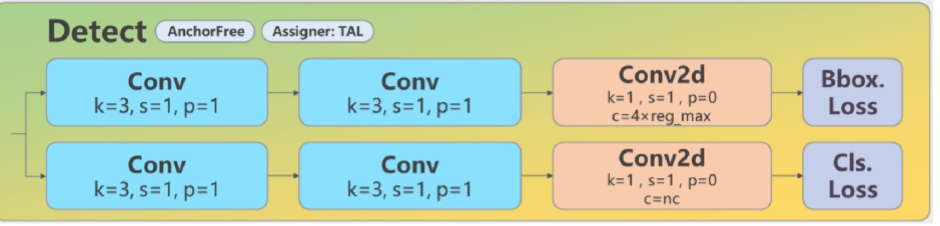

дисбаланс классов как решается 
что у нас ground truth для ячейки в которой нет самолёта

LDFL​=wl​CE(p,yl​)+wr​CE(p,yr​)

$L_{DFL}(P_i, P_{i+1}) = - \left( (y_{i+1} - y) \log(P_i) + (y - y_i) \log(P_{i+1}) \right)$

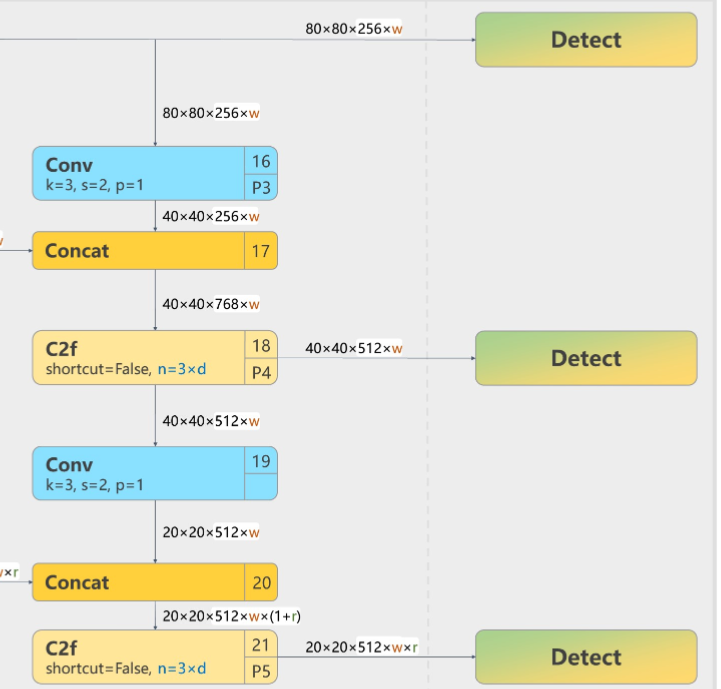

In [ ]:
model = YOLO('yolov8n.pt')
model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=1024,
    batch=16,
    patience=15,
    lr0=0.01,
    cos_lr=True,
    close_mosaic=10,
    amp=True,
    device=0,
    workers=8,
    seed=13,
    plots=True,
    save=True,
    project=str(BASE_DIR / 'runs'),
    name='hrplanes',
)



Ultralytics 8.4.48 🚀 Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hrplanes-2, nbs=64, nms=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x775e2e3dd960>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

best_model_path = BASE_DIR / 'runs' / 'hrplanes-2' / 'weights' / 'best.pt'

if best_model_path.exists():

    trained_model = YOLO(str(best_model_path))

    test_img_path = BASE_DIR / 'dataset/test/images'
    
    results = trained_model.predict(
        source=str(test_img_path),
        imgsz=1024,
        conf=0.25,      
        save=True,      
        project=str(BASE_DIR / 'runs'),
        name='predictions'
    )
    
    print(f"Предсказания сохранены в папку: {BASE_DIR / 'runs' / 'predictions'}")
else:
    print(f"Файл весов не найден по пути: {best_model_path}")
   


image 1/310 /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/test/images/AMST_039.jpg: 608x1024 17 Planes, 27.4ms
image 2/310 /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/test/images/AMST_043.jpg: 608x1024 1 Plane, 3.0ms
image 3/310 /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/test/images/AMST_052.jpg: 608x1024 7 Planes, 2.9ms
image 4/310 /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/test/images/AMST_055.jpg: 608x1024 3 Planes, 2.8ms
image 5/310 /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/test/images/AMST_060.jpg: 608x1024 3 Planes, 2.8ms
image 6/310 /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/test/images/AMST_071.jpg: 608x1024 6 Planes, 2.8ms
image 7/310 /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/test/images/AMST_072.jpg: 608x1024 15 Planes, 2.9ms
image 8/310 /home/cyberpsychoz/

In [7]:

print("--- Валидация ---")
val_metrics = trained_model.val() 
print(f"mAP50 (val): {val_metrics.box.map50:.4f}")
print(f"mAP50-95 (val): {val_metrics.box.map:.4f}")
print(f"Precision (val): {val_metrics.box.mp:.4f}")
print(f"Recall (val): {val_metrics.box.mr:.4f}")

print("\n--- Тестирование ---")
test_metrics = trained_model.val(split='test') 
print(f"mAP50 (test): {test_metrics.box.map50:.4f}")
print(f"mAP50-95 (test): {test_metrics.box.map:.4f}")
print(f"Precision (test): {test_metrics.box.mp:.4f}")
print(f"Recall (test): {test_metrics.box.mr:.4f}")

--- Валидация ---
Ultralytics 8.4.48 🚀 Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 7806MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1484.7±1100.9 MB/s, size: 3048.9 KB)
val: Scanning /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/dataset/val/labels.cache... 616 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 617/617 95.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 4.4it/s 9.0s0.1s
                   all        617       3279      0.991      0.986      0.992      0.861
Speed: 1.3ms preprocess, 3.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /home/cyberpsychoz/NSU_studying-IIR/2_course/2_sem/AI/Laboratory_3/runs/detect/val-5
mAP50 (val): 0.9918
mAP50-95 (val): 0.8611
Precision (val): 0.9908
Recall (val): 0.9864

--- Тестирование ---
Ultralytics 8.4.48 🚀 Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 4070 